## Curso: MACHINE LEARNING CLASIFICACIÓN Y REGRESIÓN

## Módulo 3: Aprendizaje supervisado
## Unidad 1: Entrenamiento

🧩 Objetivo

- Entrenar modelos supervisados de regresión y clasificación
- Usar algoritmos: regresión lineal y logística

## Importación de librerias

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score,    precision_score,    recall_score,    f1_score,    confusion_matrix

# Regresión lineal simple

Descripción del dataset:

Datos socioeconómicos de Boston para predecir valor de viviendas.

**CRIM**: tasa de delincuencia per cápita por ciudad

**INDUS:** proporción de acres de negocios no minoristas por ciudad

**RM:** número promedio de habitaciones por vivienda

**DIS:** distancias ponderadas a cinco centros de empleo de Boston

**MEDV:** valor mediano de las viviendas ocupadas por sus propietarios en miles de dólares ($1000)

In [2]:
df = pd.read_csv("/content/housing_modificado.csv")

df.head()

,DIS,INDUS,CRIM,RM,MEDV
0,4.0900,2.31,0.00632,6.575,24.0
1,4.9671,7.07,0.02731,6.421,21.6
2,4.9671,7.07,0.02729,7.185,34.7
3,6.0622,2.18,0.03237,6.998,33.4
4,6.0622,2.18,0.06905,7.147,36.2


## Selección de variables

Utilizamos sólo CRIM para evaluar un modelo simple.

In [3]:
# Asignamos las variables
X = df[['CRIM']]
y = df['MEDV']

## Split

In [4]:
# Separar en entrenamiento (80%) y prueba (20%) usando train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Modelado

In [5]:
# Crear el modelo de regresión lineal
modelo = LinearRegression()

# Entrenar el modelo con el conjunto de entrenamiento
modelo.fit(X_train, y_train)

# Hacer predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test)

# Evaluar el modelo usando R² (coeficiente de determinación)
r2 = r2_score(y_test, y_pred)

# Mostrar los resultados
print(f"Coeficiente R² del modelo: {r2:.4f}")

Coeficiente R² del modelo: 0.1587


## Vemos las correlaciones

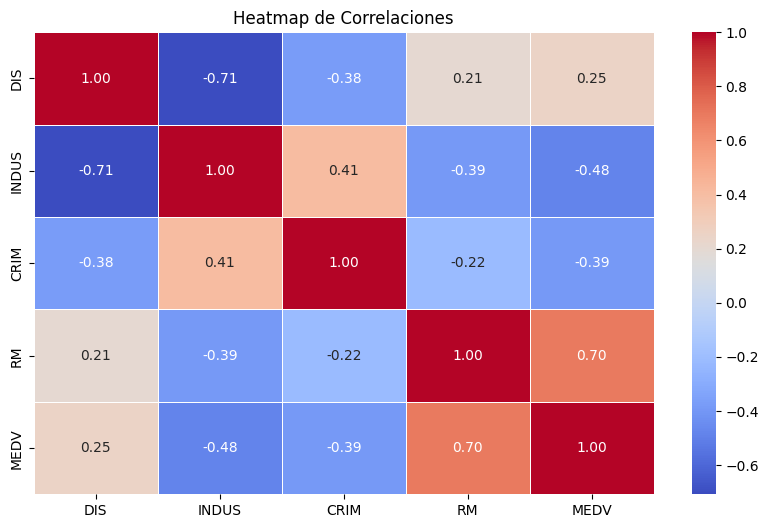

In [6]:
# Calcular la matriz de correlaciones
corr_matrix = df.corr()

# Crear el heatmap usando seaborn
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Mostrar el gráfico
plt.title('Heatmap de Correlaciones')
plt.show()

# Regresión lineal múltiple

## Selección de variables

Utilizamos las dos más correlacionadas

In [13]:
# Asignamos las variables
X = df[['RM', 'INDUS']].values
y = df['MEDV'].values.reshape(-1,1)

In [14]:
# Separar en entrenamiento (80%) y prueba (20%) usando train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear el modelo de regresión lineal
modelo = LinearRegression()

# Entrenar el modelo con el conjunto de entrenamiento
modelo.fit(X_train, y_train)

# Hacer predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test)

# Evaluar el modelo usando R² (coeficiente de determinación)
r2 = r2_score(y_test, y_pred)

# Mostrar los resultados
print(f"Coeficiente R² del modelo: {r2:.4f}")

Coeficiente R² del modelo: 0.4738


## Modelo integral: todas las variables

In [15]:
# Asignamos las variables
X = df.drop(columns=["MEDV"])
y = df["MEDV"]

# Separar en entrenamiento (80%) y prueba (20%) usando train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear el modelo de regresión lineal
modelo = LinearRegression()

# Entrenar el modelo con el conjunto de entrenamiento
modelo.fit(X_train, y_train)

# Hacer predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test)

# Evaluar el modelo usando R² (coeficiente de determinación)
r2 = r2_score(y_test, y_pred)

# Mostrar los resultados
print(f"Coeficiente R² del modelo: {r2:.4f}")

Coeficiente R² del modelo: 0.5001


In [16]:
X.shape

(506, 4)

## Regresión logística

Dataset sobre indicadores médicos donde la variable objetivo es un indicador de riesgo de diabetes (outcome).

In [18]:
diabetes = pd.read_csv("/content/diabetes.csv")

diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [19]:
diabetes.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

## Selección de variables

In [20]:
# Separamos el dataset
X = diabetes.drop(columns=["Outcome"])
y = diabetes["Outcome"]

## Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=16)

## Modelado

In [22]:
logreg = LogisticRegression()

logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Evaluación

In [23]:
cnf_matrix = confusion_matrix(y_test, y_pred)
cnf_matrix

array([[95,  7],
       [21, 31]])

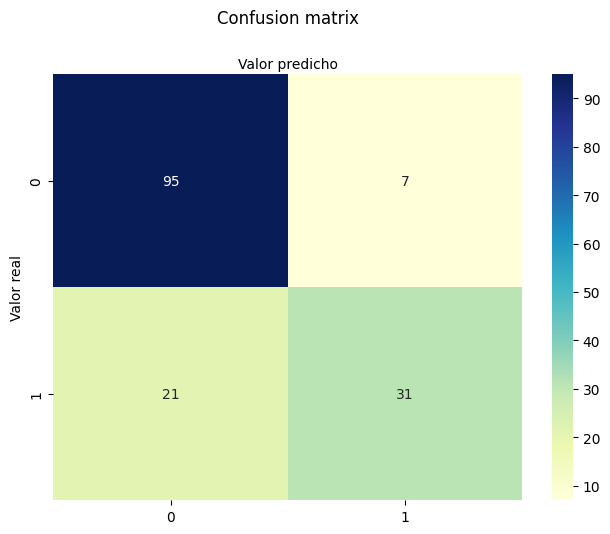

In [24]:
class_names=[0,1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Valor real')
plt.xlabel('Valor predicho')
plt.show()

* **95: Verdaderos negativos (TN).** El modelo predijo que 95 personas NO tienen diabetes y es correcto.

* **7: Falsos positivos (FP).** El modelo predijo que 7 personas tienen diabetes, pero en realidad NO tienen (Error de tipo 1).

* **21: Falsos negativos (FN).** El modelo predijo que 21 personas NO tienen diabetes, pero en realidad SÍ tienen (Error de tipo 2).

* **31: Verdaderos positivos (TP).** El modelo predijo que 31 personas tienen diabetes y es correcto.

In [25]:
print("Accuracy:", round(accuracy_score(y_test, y_pred),2))

Accuracy: 0.82


* 0.82 significa que el 82% de las predicciones del modelo fueron correctas.

In [26]:
print("Recall:", round(recall_score(y_test, y_pred),2))

Recall: 0.6


* 0.6 significa que el modelo identificó correctamente el 60% de las personas con diabetes. Esto indica que el modelo dejó escapar algunos casos (falsos negativos).

In [27]:
print("Precision:", round(precision_score(y_test, y_pred),2))

Precision: 0.82


* 0.82, lo que significa que el 82% de las personas identificadas como diabéticas por el modelo realmente tienen diabetes. El modelo tiene pocos falsos positivos.

In [28]:
print("F1 Score:", round(f1_score(y_test, y_pred),2))

F1 Score: 0.69


* 0.69 indica que el modelo tiene un rendimiento razonable considerando tanto precision como recall.

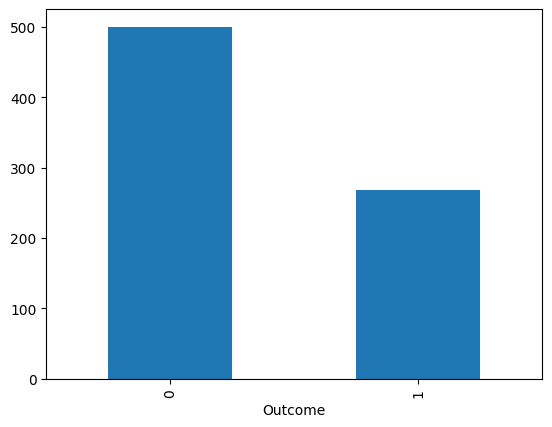

In [29]:
diabetes["Outcome"].value_counts().plot(kind="bar")
plt.show()

## Lineal simple con RM

In [17]:
# Asignamos las variables
X = df[['RM']]
y = df['MEDV']

# Separar en entrenamiento (80%) y prueba (20%) usando train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear el modelo de regresión lineal
modelo = LinearRegression()

# Entrenar el modelo con el conjunto de entrenamiento
modelo.fit(X_train, y_train)

# Hacer predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test)

# Evaluar el modelo usando R² (coeficiente de determinación)
r2 = r2_score(y_test, y_pred)

# Mostrar los resultados
print(f"Coeficiente R² del modelo: {r2:.4f}")

Coeficiente R² del modelo: 0.3708
